# 03 — Model comparison

**Goal:** compare logistic regression against random forest — beyond just the baseline — using both a held-out test set and 5-fold cross-validation, and pick which one this project ships with.

**Input:** `data/raw/wine.csv`, same split and seed as `02-baseline-model.ipynb`.

**Conclusion:** _(written after running the cells below — full log in `results/experiments.md`, including a model we tried and rejected)_

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ucu-ai-course/project-template/blob/main/notebooks/03-model-comparison.ipynb)

In [1]:
import sys

# Safe to run locally too: this block only does anything inside Google Colab, where
# the repo isn't already cloned and the package isn't already installed.
if "google.colab" in sys.modules:
    get_ipython().system("git clone https://github.com/ucu-ai-course/project-template.git")
    get_ipython().run_line_magic("cd", "project-template")
    get_ipython().system("pip install -q -r requirements.txt")
    get_ipython().system("pip install -q -e .")


In [2]:
from pathlib import Path
import os

# Notebooks are launched from notebooks/ (`jupyter lab notebooks/`), but every path in this
# project (config/, data/, models/, results/) is written relative to the repo root.
# Running this cell once makes every relative path below "just work", the same way it
# does for the CLI and scripts/.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(PROJECT_ROOT)
PROJECT_ROOT


PosixPath('/Users/oleksandr/Documents/GitHub/project-template')

In [3]:
from wine_origin.config import load_config
from wine_origin.data import (
    load_raw_csv,
    split_features_target,
    train_test_split_stratified,
)
from wine_origin.evaluate import compute_metrics, cross_validate_accuracy
from wine_origin.models import build_logistic_regression, build_random_forest
from wine_origin.utils import set_seed

config = load_config("config/default.yaml")
set_seed(config["seed"])

df = load_raw_csv(config["paths"]["raw_data"])
train_df, test_df = train_test_split_stratified(
    df, test_size=config["split"]["test_size"], seed=config["seed"]
)
X_train, y_train = split_features_target(train_df)
X_test, y_test = split_features_target(test_df)
X_all, y_all = split_features_target(df)

In [4]:
import pandas as pd

candidates = {
    "logistic_regression": build_logistic_regression(config),
    "random_forest": build_random_forest(config),
}

rows = []
for name, model in candidates.items():
    model.fit(X_train, y_train)
    metrics = compute_metrics(y_test, model.predict(X_test))
    cv = cross_validate_accuracy(
        model, X_all, y_all, n_splits=config["cv"]["n_splits"], seed=config["seed"]
    )
    rows.append(
        {
            "model": name,
            "test_accuracy": metrics["accuracy"],
            "test_macro_f1": metrics["macro_f1"],
            "cv_mean_accuracy": cv["cv_mean_accuracy"],
            "cv_std_accuracy": cv["cv_std_accuracy"],
        }
    )

comparison = pd.DataFrame(rows).set_index("model").round(4)
comparison

,test_accuracy,test_macro_f1,cv_mean_accuracy,cv_std_accuracy
model,,,,
logistic_regression,0.9722,0.971,0.9833,0.0136
random_forest,1.0000,1.000,0.9775,0.0213


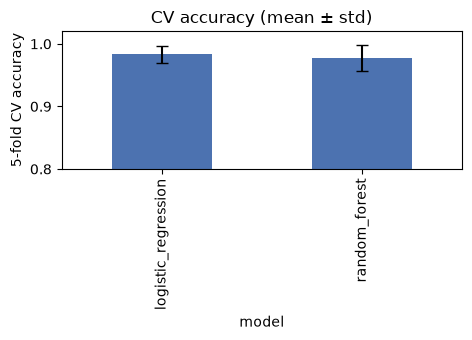

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 3.5))
comparison["cv_mean_accuracy"].plot.bar(
    ax=ax, yerr=comparison["cv_std_accuracy"], capsize=4, color="#4C72B0"
)
ax.set_ylabel("5-fold CV accuracy")
ax.set_ylim(0.8, 1.02)
ax.set_title("CV accuracy (mean ± std)")
fig.tight_layout()

We also tried an out-of-the-box `SVC()` — it scored well below both models above (see the `svm_default` entry in `results/experiments.md`) and we didn't tune it further, since logistic regression already met our bar. That's documented there as a negative result, not silently dropped.

## Conclusion

On the single test split, random forest happens to score highest — but 5-fold CV (the more trustworthy comparison; see the table above) shows logistic regression has both a higher mean accuracy *and* a lower standard deviation. With only 36 test samples, a single split is easy to over-read: one flipped prediction moves accuracy by about 2.8 percentage points, enough to flip the ranking. We selected **logistic regression** as the project's primary model based on the CV numbers, and because it's simpler to explain than a 200-tree forest. Full reasoning and the rejected SVM run: `results/experiments.md`.